# Four-mode GKP Hamiltonian: flux spectra and KITE asymmetry

calculates the ground-state transition frequencies

$$
f_{0k}=\frac{E_k-E_0}{h}
$$

of the four-mode Gridium Hamiltonian.

For each parameter regime, it reproduces the five sweep types:

1. Main-loop flux $\varphi_{\mathrm{ext}}$ with $\vartheta_{\mathrm{ext}}=0$.
2. Main-loop flux $\varphi_{\mathrm{ext}}$ with $\vartheta_{\mathrm{ext}}=\pi$.
3. KITE flux $\vartheta_{\mathrm{ext}}$ with $\varphi_{\mathrm{ext}}=0$.
4. KITE flux $\vartheta_{\mathrm{ext}}$ with $\varphi_{\mathrm{ext}}=\pi$.
5. Offset charge $n_g$ at the protected point
   $(\varphi_{\mathrm{ext}},\vartheta_{\mathrm{ext}})=(0,\pi)$.

- Solid lines: symmetric four-mode circuit. 
- Dashed lines:  same hamiltonian with Josephson and inductive KITE asymmetry.

## load and prepare the environment ##

In [24]:
import os
import sys
from pathlib import Path

#each eigensolve should use one numerical-library thread.
#parallelism will be applied across independent sweep points.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/gridium-mpl")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

#find the repository root whether Jupyter starts in the repository root or inside the Notebooks directory.
ROOT = Path.cwd().resolve()

if not (ROOT / "Circuit_Objs").is_dir():
    for candidate in ROOT.parents:
        if (candidate / "Circuit_Objs").is_dir():
            ROOT = candidate
            break
    else:
        raise RuntimeError(
            "The notebook must be run from inside the 2q_gridium repository."
        )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Circuit_Objs.qchard_gridium_netlist import Gridium4Mode

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

print("Repository root:", ROOT)

Repository root: /Users/eric_jin/2q_gridium-main


## physical parameters and numerical cutoff ##

In [25]:
#from Simulations.four_mode_gkp.four_mode_s5_asymmetry_spectra import N_TRANSITIONS
from Circuit_Objs.qchard_gridium_netlist import Gridium4Mode

PRESET  = "preview"
WORKERS = 2
SAVE_FIGURE = True 

PRESETS = {

    "preview": {
        "cutoffs": {
            "n1max": 3,
            "N2": 31,
            "L2": 11.0,
            "N3": 31,
            "L3": 14.0,
            "N4": 6,
            "nkeep": 40,
        },
        "flux_points": 9,
        "charge_points": 7,
    },

    "high_cutoff": {
        "cutoffs": {
            "n1max": 5,
            "N2": 131,
            "L2": 11.0,
            "N3": 101,
            "L3": 14.0,
            "N4": 8,
            "nkeep": 360,
        },
        "flux_points": 25,
        "charge_points": 21,
    },

}

CONFIG = PRESETS[PRESET]

#get the energies to get frequencies
N_TRANSITIONS = 5
N_LEVELS = N_TRANSITIONS + 1

#additional charging energies in four-mode hamiltonian 
FOUR_MODE_CAPS = {
    "eC": 5.5, 
    "eP": 10.0, 
}

#KITE asymmetry
ASYMMETRY = {
    "eps_J": 0.10, 
    "eps_LK": 0.05, 
}

#regimes a-d
REGIMES = {
    "a": {
        "EJ": 5.0, "EC": 0.5,
        "EL": 1.0, "ELK": 1.0,
        "EJS": 4.0, "ECS": 8.0,
    },
    "b": {
        "EJ": 10.0, "EC": 0.5,
        "EL": 1.0, "ELK": 1.0,
        "EJS": 4.0, "ECS": 8.0,
    },
    "c": {
        "EJ": 10.0, "EC": 0.5,
        "EL": 0.5, "ELK": 0.5,
        "EJS": 4.0, "ECS": 8.0,
    },
    "d": {
        "EJ": 10.0, "EC": 0.5,
        "EL": 0.2, "ELK": 0.2,
        "EJS": 4.0, "ECS": 8.0,
    },
}

RESULTS_DIR = ROOT / "Simulations" / "four_mode_gkp" / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Preset:", PRESET)
print("Cutoffs:", CONFIG["cutoffs"])
print("Workers:", WORKERS)
print("Asymmetry:", ASYMMETRY)

Preset: preview
Cutoffs: {'n1max': 3, 'N2': 31, 'L2': 11.0, 'N3': 31, 'L3': 14.0, 'N4': 6, 'nkeep': 40}
Workers: 2
Asymmetry: {'eps_J': 0.1, 'eps_LK': 0.05}


## build the cached parallel evaluator ##

In [26]:
import json
import hashlib
import time

from pathos.pools import ProcessPool

FORCE_RECOMPUTE = False

CACHE_PATH = (
    RESULTS_DIR
    / f"four_mode_s5_cache_{PRESET}.json"
)

print("Cache file:", CACHE_PATH)

Cache file: /Users/eric_jin/2q_gridium-main/Simulations/four_mode_gkp/results/four_mode_s5_cache_preview.json


## computes the simulation and saves to JSON cache ##

In [27]:
#helper function converting numpy objects into ordinary python values 
def _plain(value):
    if isinstance(value, dict):
        return {
            str(key): _plain(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [_plain(item) for item in value]

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, (np.floating, np.integer)):
        return value.item()

    return value

#creates a unique key for one hamiltonian parameter point
def _case_key(case):
    payload = json.dumps(
        _plain(case),
        sort_keys=True,
        separators=(",", ":"),
    )

    return hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()[:20]

#calculates the transition frequency for one parameter point
def _solve_case(case):

    model = Gridium4Mode(**case)

    energies = np.asarray(
        model.levels(nlev=case["nlev"]),
        dtype=float,
    )

    transitions = energies - energies[0]

    return transitions.tolist()


#writes completed simulation results into a JSON cache 
def _write_cache(cache):
    temporary_path = CACHE_PATH.with_suffix(".tmp")

    temporary_path.write_text(
        json.dumps(cache, sort_keys=True)
    )

    temporary_path.replace(CACHE_PATH)

def evaluate_cases (cases, workers = 1, batch_size = 12): 
    cases = [_plain(case) for case in cases] #normalization key 
    keys = [_case_key(case) for case in cases] #converts every case into JSON values with unique keys 

    if CACHE_PATH.exists() and not FORCE_RECOMPUTE: 
        cache = json.loads(CACHE_PATH.read_text())
    else: 
        cache = {}
    
    unique_missing = {}

    for key, case in zip(keys, cases):
        if key not in cache: 
            unique_missing[key] = case 

    missing_items = list(unique_missing.items())

    print(
        f"Requested {len(cases)} points; "
        f"{len(missing_items)} unique points are missing."
    )

    #if at least one requested parameters point is absent from the cache 
    if missing_items: 
        started = time.time()

        if workers > 1: 
            pool = ProcessPool(
                nodes = min(workers, len(missing_items))
            )
        else: 
            pool = None

        try: #worker processes can be cleaned up if a calculation failed
            for start in range (
                0, 
                len(missing_items), 
                batch_size, 
            ): 
                batch = missing_items[
                    start: start + batch_size
                ]

                batch_cases = [
                    case
                    for _, case in batch 
                ]

                if pool is not None: 
                    values = list (
                        pool.map(_solve_case, batch_cases) #distribute the hamiltonian cases across worker process
                    )
                else: 
                    values = [
                        _solve_case(case)
                        for case in batch_cases
                    ]

                for (key, _), value in zip(batch, values): #updating cache
                    cache[key]  = value 

                _write_cache(cache)

                #reports progress after every completed and cached batch 
                completed = min(
                    start + len(batch), 
                    len(missing_items), 
                )

                elapsed = time.time() - started 

                print(
                    f"Solved {completed}/{len(missing_items)} "
                    f"missing points in {elapsed / 60:.1f} minutes."
                )

        #cleanup  
        except BaseException: 
            if pool is not None: 
                pool.terminate()
            raise 

        else: 
            if pool is not None: 
                pool.close()
                pool.join()
        
        finally: 
            if pool is not None: 
                pool.clear()
        
    return np.asarray(
        [cache[key] for key in keys],  #final shape: (N_cases, N_levels)
        dtype = float, 
    )


## sweep setup and definitions ##

In [28]:
phi_values = np.linspace (
    0.0, 
    2.0 * np.pi, 
    CONFIG["flux_points"]
)

theta_values = np.linspace ( # KITE-loop flux 
    0.0, 
    2.0 * np.pi, 
    CONFIG["flux_points"]
)

ng_values = np.linspace(
    0.0, 
    1.0, 
    CONFIG["charge_points"]
)

cases = [] # hold every complete hamiltonian parameter dictionary 
registry = {} #record which rows of cases belong to each plotted curve 

#creates on complete spectrum series 
def register_series (
    label, 
    base_parameters, 
    parameter, 
    values, 
    fixed_parameters, 
    asymmetry,
): 
    indices = []

    for value in values: 
        case = dict(base_parameters)

        case.update(FOUR_MODE_CAPS)
        case.update(CONFIG["cutoffs"])
        case.update(fixed_parameters)
        case.update(asymmetry)

        case[parameter] = float(value)
        case['nlev'] = N_LEVELS

        indices.append(len(cases))
        cases.append(case)

    registry[label] = np.asarray(
        indices, 
        dtype = int, 
    )

#panel definitions 
PANEL_SPECS = {

    "phi_theta0": (
        "phi_ext", 
        phi_values, 
        {
            "theta_ext": 0.0, 
            "phi_ext": 0.0, 
            "ng": 0.0, 
        }, 
    ), 

    "phi_thetapi": ( #sweep phi while keep theta as pi 
        "phi_ext", 
        phi_values, 
        {
            "theta_ext": np.pi, 
            "phi_ext": 0.0, 
            "ng": 0.0, 
        }, 
    ),

    "theta_phi0": (
        "theta_ext", 
        theta_values, 
        {
            "phi_ext": 0.0, 
            "theta_ext": 0.0, 
            "ng": 0.0, 
        }, 
    ), 

    "theta_phipi": (
        "theta_ext", 
        theta_values, 
        {
            "phi_ext": np.pi, 
            "theta_ext": 0.0, 
            "ng": 0.0, 
        }, 
    ), 

    "charge": (
        "ng", 
        ng_values, 
        {
            "phi_ext": 0.0, 
            "theta_ext": np.pi, 
            "ng": 0.0, 
        }, 
    ), 
}

In [29]:
for regime_name, regime_parameters in REGIMES.items(): #iterate through a-d
    for panel_name, panel_spec in PANEL_SPECS.items(): #iterate through five panels 
        parameter, values, fixed_parameters = panel_spec

        #create one graph for symmetric, one graph for asymmetric 
        register_series (
            label=f"{regime_name}:{panel_name}:symmetric", 
            base_parameters= regime_parameters, 
            parameter = parameter, 
            values = values, 
            fixed_parameters=fixed_parameters, 
            asymmetry = {
                "eps_J": 0.0, 
                "eps_LK": 0.0, 
            }, 
        )

        register_series (
            label=f"{regime_name}:{panel_name}:asymmetric", 
            base_parameters=regime_parameters, 
            parameter = parameter, 
            values = values, 
            fixed_parameters=fixed_parameters, 
            asymmetry = ASYMMETRY, 
        )

print("Registered parameter points:", len(cases))
print("Registered spectrum series:", len(registry))

Registered parameter points: 344
Registered spectrum series: 40


In [30]:
#diagonalization
energy_table = evaluate_cases (
    cases, 
    workers=WORKERS, 
)

Requested 344 points; 0 unique points are missing.


In [31]:
#reorganize the rows into named spectrum curves
spectra = {
    label: energy_table[indices]
    for label, indices in registry.items()
}

#consistency check 
assert energy_table.shape == (len(cases), N_LEVELS)
assert np.all(np.isfinite(energy_table))

assert np.allclose( #should return energies relative to the ground state 
    energy_table[:, 0],
    0.0,
    atol=1e-10,
)

print("Energy table shape:", energy_table.shape)
print("Number of spectrum series:", len(spectra))

Energy table shape: (344, 6)
Number of spectrum series: 40


## plotting ##

Saved: /Users/eric_jin/2q_gridium-main/Simulations/four_mode_gkp/results/four_mode_s5_style_preview.png


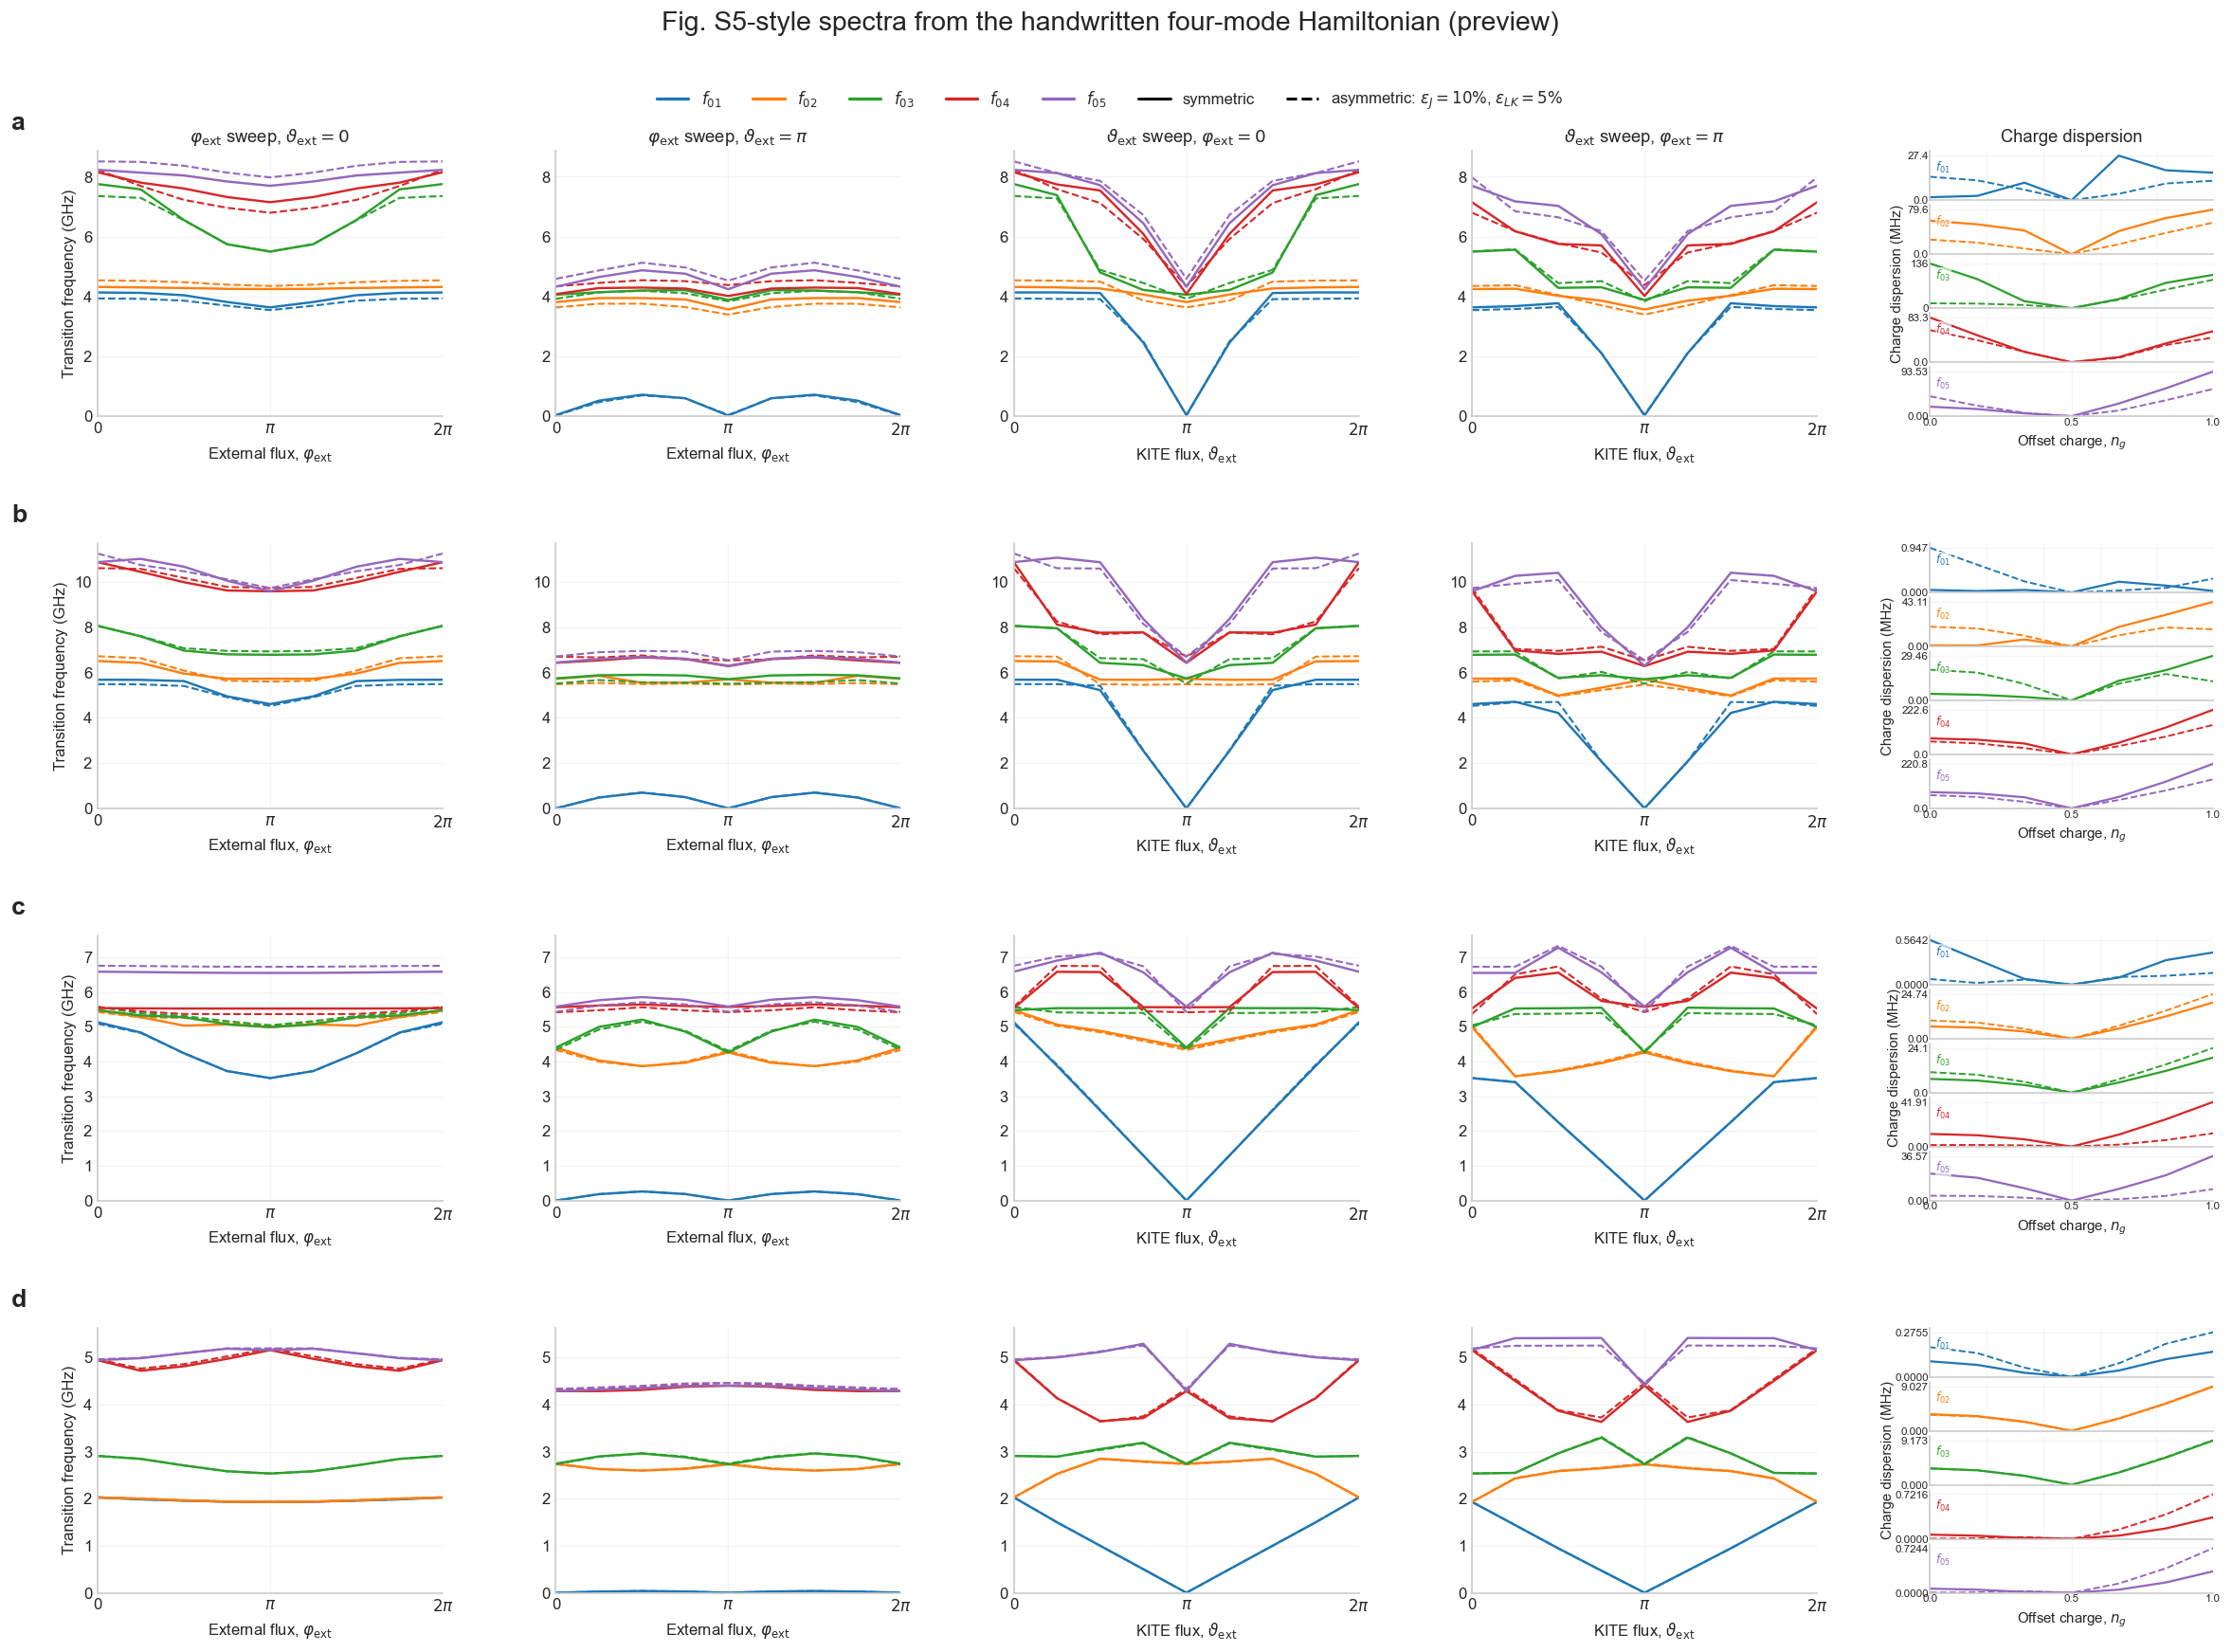

In [32]:
transition_colors = plt.get_cmap("tab10").colors[:N_TRANSITIONS]

row_names = list(REGIMES)
spectrum_panels = ["phi_theta0", "phi_thetapi", "theta_phi0", "theta_phipi"]

panel_titles = [
    r"$\varphi_{\mathrm{ext}}$ sweep, $\vartheta_{\mathrm{ext}}=0$",
    r"$\varphi_{\mathrm{ext}}$ sweep, $\vartheta_{\mathrm{ext}}=\pi$",
    r"$\vartheta_{\mathrm{ext}}$ sweep, $\varphi_{\mathrm{ext}}=0$",
    r"$\vartheta_{\mathrm{ext}}$ sweep, $\varphi_{\mathrm{ext}}=\pi$",
]


def format_flux_axis(ax, symbol):
    ax.set_xlim(0.0, 2.0 * np.pi)
    ax.set_xticks([0.0, np.pi, 2.0 * np.pi], ["0", r"$\pi$", r"$2\pi$"])
    ax.set_xlabel(symbol)
    ax.grid(alpha=0.22)


fig = plt.figure(figsize=(20, 15))
outer = fig.add_gridspec(
    4, 5, width_ratios=[1.0, 1.0, 1.0, 1.0, 0.82],
    left=0.055, right=0.985, bottom=0.055, top=0.90,
    wspace=0.34, hspace=0.48,
)

for row_index, regime_name in enumerate(row_names):
    row_max = 0.0
    for panel_name in spectrum_panels:
        for variant in ("symmetric", "asymmetric"):
            spectrum = spectra[f"{regime_name}:{panel_name}:{variant}"]
            row_max = max(row_max, float(np.max(spectrum[:, 1:])))

    for column_index, panel_name in enumerate(spectrum_panels):
        ax = fig.add_subplot(outer[row_index, column_index])
        symmetric = spectra[f"{regime_name}:{panel_name}:symmetric"]
        asymmetric = spectra[f"{regime_name}:{panel_name}:asymmetric"]
        x = phi_values if column_index < 2 else theta_values

        for level in range(1, N_LEVELS):
            color = transition_colors[level - 1]
            ax.plot(x, symmetric[:, level], color=color, linewidth=1.45)
            ax.plot(
                x, asymmetric[:, level], color=color,
                linewidth=1.25, linestyle="--",
            )

        ax.set_ylim(0.0, 1.04 * row_max)
        flux_label = (
            r"External flux, $\varphi_{\mathrm{ext}}$"
            if column_index < 2
            else r"KITE flux, $\vartheta_{\mathrm{ext}}$"
        )
        format_flux_axis(ax, flux_label)

        if column_index == 0:
            ax.set_ylabel("Transition frequency (GHz)")
            ax.text(
                -0.25, 1.08, regime_name, transform=ax.transAxes,
                fontsize=16, fontweight="bold",
            )
        if row_index == 0:
            ax.set_title(panel_titles[column_index], fontsize=11)

    charge_grid = outer[row_index, 4].subgridspec(N_TRANSITIONS, 1, hspace=0.10)
    charge_symmetric = spectra[f"{regime_name}:charge:symmetric"]
    charge_asymmetric = spectra[f"{regime_name}:charge:asymmetric"]
    center = int(np.argmin(np.abs(ng_values - 0.5)))

    for level in range(1, N_LEVELS):
        ax = fig.add_subplot(charge_grid[level - 1, 0])
        symmetric_dispersion = 1e3 * np.abs(
            charge_symmetric[:, level] - charge_symmetric[center, level]
        )
        asymmetric_dispersion = 1e3 * np.abs(
            charge_asymmetric[:, level] - charge_asymmetric[center, level]
        )
        color = transition_colors[level - 1]
        ax.plot(ng_values, symmetric_dispersion, color=color, linewidth=1.35)
        ax.plot(
            ng_values, asymmetric_dispersion, color=color,
            linewidth=1.15, linestyle="--",
        )
        ymax = max(
            float(np.max(symmetric_dispersion)),
            float(np.max(asymmetric_dispersion)),
            0.01,
        )
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(0.0, 1.10 * ymax)
        ax.set_yticks([0.0, ymax])
        ax.tick_params(axis="both", labelsize=7, pad=1)
        ax.text(
            0.02, 0.82, rf"$f_{{0{level}}}$",
            transform=ax.transAxes, color=color, fontsize=7, va="top",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=0.4),
        )
        ax.grid(alpha=0.18)
        if level < N_TRANSITIONS:
            ax.set_xticklabels([])
        else:
            ax.set_xticks([0.0, 0.5, 1.0])
            ax.set_xlabel(r"Offset charge, $n_g$", fontsize=9)
        if level == 3:
            ax.set_ylabel("Charge dispersion (MHz)", fontsize=9)
        if row_index == 0 and level == 1:
            ax.set_title("Charge dispersion", fontsize=11)

legend_handles = [
    Line2D(
        [0], [0], color=transition_colors[level - 1], linewidth=2,
        label=rf"$f_{{0{level}}}$",
    )
    for level in range(1, N_LEVELS)
]
legend_handles += [
    Line2D([0], [0], color="black", linewidth=1.8, label="symmetric"),
    Line2D(
        [0], [0], color="black", linewidth=1.8, linestyle="--",
        label=(
            rf"asymmetric: $\epsilon_J={100 * ASYMMETRY['eps_J']:.0f}\%$, "
            rf"$\epsilon_{{LK}}={100 * ASYMMETRY['eps_LK']:.0f}\%$"
        ),
    ),
]
fig.legend(
    handles=legend_handles, loc="upper center", ncol=len(legend_handles),
    bbox_to_anchor=(0.5, 0.945), frameon=False,
)
fig.suptitle(
    f"Fig. S5-style spectra from the handwritten four-mode Hamiltonian ({PRESET})",
    fontsize=17, y=0.982,
)

s5_path = RESULTS_DIR / f"four_mode_s5_style_{PRESET}.png"
if SAVE_FIGURE:
    fig.savefig(s5_path, bbox_inches="tight", dpi=200)
    print("Saved:", s5_path)

plt.show()
